This notebook and saves an ortho on the shendure data as preprocessed in `preprocessing` & demonstrates that estimated nb parameters track closely with UMI means, as expected.


# Setup

In [1]:
#imports
import pandas as pd
import numpy as np
import time
import pickle
from pathlib import Path
from formulaic import Formula
import seaborn as sns
import matplotlib.pyplot as plt
import os
import signal
from tensorzinb.tensorzinb import TensorZINB
import scMPRAforge as scm

In [2]:
#create dask cluster

from dask_jobqueue import SLURMCluster
from dask.distributed import Client, performance_report

local=True
if not local:
    worker_cores = 1
    worker_memory = "96G"
    worker_processes = 1
    cluster_jobs = 16

    cluster=SLURMCluster(
        cores=worker_cores,#cores per slurm job
        memory=worker_memory,#memory per slurm job
        processes=worker_processes,#dask workers per slurm job
        job_extra_directives=["-p ycga", 
            f"--job-name=simclust_worker",
            f"--time=2-23:40:00",
            f"--output=worker_%j.out"]
    )

    cluster.scale(jobs=cluster_jobs)

    client = Client(cluster,
            timeout=f"{5*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s"  # Worker heartbeat interval
        )
else:
    from dask.distributed import Client, LocalCluster
    cluster=LocalCluster(n_workers=1)
    client = Client(cluster)

2026-03-22 14:40:19,513 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='r814u03n08.mccleary.ycrc.yale.edu:42892', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.ex

In [3]:
client.dashboard_link

'http://127.0.0.1:8787/status'

# Describe with an ortho

Set paths

In [4]:
#data_root="/nfs/roberts/project/pi_skr2/shared/tabula_data"
data_root="/vast/palmer/pi/reilly/tabula_data"
path=f"{data_root}/shendure"
name="shendure_ortho_consider_missing_20260320"
report_path = Path(name + "_dask_performance_report.html")

Next, clean the data format

In [ ]:
shendure_data_raw=pd.read_csv(f"{path}/shendure_counts_not_grouped.txt",sep="\t")

In [ ]:
cols=list(scm.MPRA_UMIWISE_ALLOWED)
cols.remove("reads_DNA")
cols

In [ ]:
shendure_data_reduced=shendure_data_raw[cols]
shendure_data_reduced.to_csv(f"{path}/shendure_processed.tsv",sep="\t", index=False)

In [5]:

if os.path.isdir(path+"/"+name):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name)
    shendure=primordial.training_data
else:
    print("[+] Model not found. Creating...")

    #load data
    shendure=scm.scMPRA_data.from_tsv(f"{path}/shendure_processed.tsv")
    shendure.set_negative_controls(["minP","noP"])
    shendure.set_reference_cell("Pluripotent")
    shendure.ortho_filter()
    
    shendure.set_consider_missing(True)

    primordial=scm.ortho()
    primordial.criss_cross(client=client,
                        dat=shendure)
    primordial.extract_params(client)
    primordial.save(path,name,client=client)

[+] Model found. Loading...


# Examine QC metrics

In [6]:
primordial.compute_model_qc()

In [7]:
by_cre_thetas=[]
for key in primordial.by_cre.model:
    by_cre_thetas.append(primordial.by_cre.model[key].result()["weights"]["theta"].squeeze())
by_cre_thetas=np.array(by_cre_thetas)

by_cell_type_thetas=[]
for key in primordial.by_cell_type.model:
    by_cell_type_thetas.append(primordial.by_cell_type.model[key].result()["weights"]["theta"].squeeze())
by_cell_type_thetas=np.array(by_cell_type_thetas)


<Axes: >

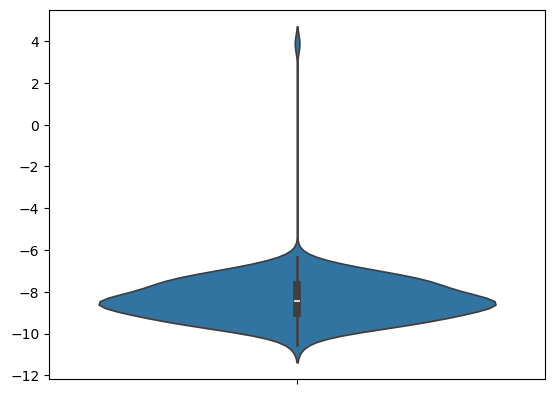

In [8]:
sns.violinplot(by_cre_thetas)

<Axes: >

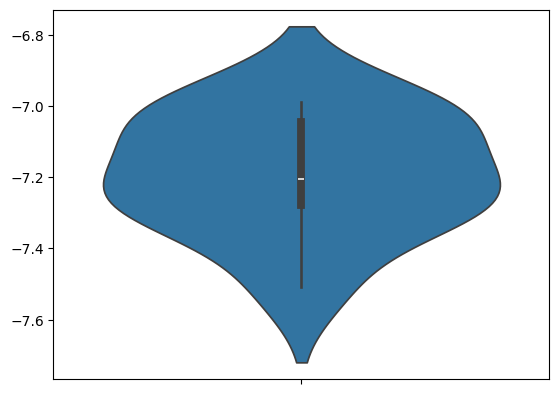

In [9]:
sns.violinplot(by_cell_type_thetas)

In [10]:
np.mean(by_cre_thetas)

np.float32(-8.350948)

In [11]:
np.mean(by_cell_type_thetas)

np.float32(-7.191144)

In [12]:
np.mean(np.concatenate((by_cre_thetas,by_cell_type_thetas)))

np.float32(-8.297747)

Let's look at the mu min & max : none should be below zero, none should be above 1000.

In [13]:
def minimax(QC):
    x=[]
    for level in QC.keys():
        if QC[level]["success"]:
            x.append(QC[level]["dat"])
    x=pd.concat(x)
    print(f"min {min(x['mu'])}, max {max(x['mu'])}")

print("cre")
minimax(primordial.by_cre_qc)
print("ct")
minimax(primordial.by_cell_qc)

cre
min 1.6592315432717442e-07, max 1.679967999458313
ct
min 0.0, max 1.9402974843978882


Now let's look at the correlations.

---
---
[np.float64(0.9996696368178204), np.float64(0.9986680414547341), np.float64(0.9990298843338768), np.float64(0.9963050721602709), np.float64(0.9971311634955202), np.float64(0.9724198667045715), np.float64(0.9967558382871933), np.float64(0.9999921026409895), np.float64(0.9999868540301635), np.float64(0.9673788919959226), np.float64(0.9961889962978127), np.float64(0.9980592427318591), np.float64(0.9958049133273716), np.float64(0.995254957220989), np.float64(0.9938156823510093), np.float64(0.9971185877254338), np.float64(0.9880464063360357), np.float64(0.9928878829288438), np.float64(0.9989381113632072), np.float64(0.9999826319052603), np.float64(0.9997287578231948), np.float64(0.9984414845189117), np.float64(0.9999497253527804), np.float64(0.9969446601959965), np.float64(0.9955916001505136), np.float64(0.9984492368352049), np.float64(0.995623514256437), np.float64(0.9967634854588147), np.float64(0.9999530016198557), np.float64(0.9711846674057328), np.float64(0.984569565874473), np

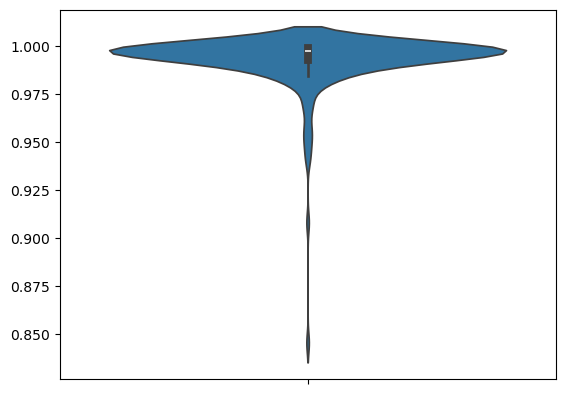

In [14]:
r=[]
for QC in [primordial.by_cre_qc,primordial.by_cell_qc]:
    print("---")
    
    for level in QC.keys():
        if QC[level]["success"]:
            if np.isnan(QC[level]["r_value"]):
                print(f"nan in {level}")
            else:
                if QC[level]["r_value"]<0.8:
                    print(f"low r {level}")
                r.append(QC[level]["r_value"])


sns.violinplot(r)

print(r)
#print(np.mean(r))
#for cell_type in QC:
#    print(f"{cell_type} : r={QC[cell_type]['r_value']}, slope={QC[cell_type]['slope']}")

Correlations generally look pretty good.

In [15]:
cluster.close()
client.close()

2026-03-22 14:51:17,440 - distributed.nanny - WARNING - Worker process still alive after 4.0 seconds, killing
